lsgo

#1 spectral diff 1d

In [ ]:
import numpy as np
L = 128        # System size
N = 3000       # Total no. of iterations
delt = 0.1     # temporal step size/resolution
delx = 0.3     # spatial step size/resolution
D = 0.005      # Diffusion constant

c = np.zeros(L)
c0 = np.zeros(L)
K = (2 * np.pi / (L * delx)) * np.concatenate((
    np.arange(0, L//2),
    np.arange(-L//2, 0)
))

# Spatial grid
x = np.arange(1, L + 1)

# Gaussian initial condition
c0 = np.exp(-((x - L/2) * delx / 5)**2)
c = c0.copy()

# FFT
cc = np.fft.fft(c)

# Storage for time evolution
cT = np.zeros((L, N))

# Time loop
for i in range(N):
    for p in range(L):
        cc[p] = cc[p] - D * delt * (K[p]**2) * cc[p]
    # Vectorized alternative (same as commented MATLAB line):
    # cc = cc - D * delt * (K**2) * cc

    cT[:, i] = np.real(np.fft.ifft(cc))

# Optional parameter
Neumann_par = D * delt / (delx * delx)

#2 spectral advection   

In [1]:
import numpy as np

# Parameters
L = 128        # System size
N = 3000       # Total no. of iterations
delt = 0.01    # temporal step size (smaller than diffusion for stability)
delx = 0.3     # spatial step size

# Arrays
y = np.zeros(L)
y0 = np.zeros(L)

# k modes (same construction)
K = (2 * np.pi / (L * delx)) * np.concatenate((
    np.arange(0, L//2),
    np.arange(-L//2, 0)
))

# Spatial grid
x = np.arange(1, L + 1)

# Initial condition (Gaussian pulse)
y0 = np.exp(-((x - L/2) * delx / 5)**2)
y = y0.copy()

# FFT
yy = np.fft.fft(y)

# Storage
yT = np.zeros((L, N))

# Time loop
for i in range(N):
    for p in range(L):
        yy[p] = yy[p] + delt * (1j * K[p]) * yy[p]
    # Vectorized version:
    # yy = yy + delt * (1j * K) * yy

    yT[:, i] = np.real(np.fft.ifft(yy))

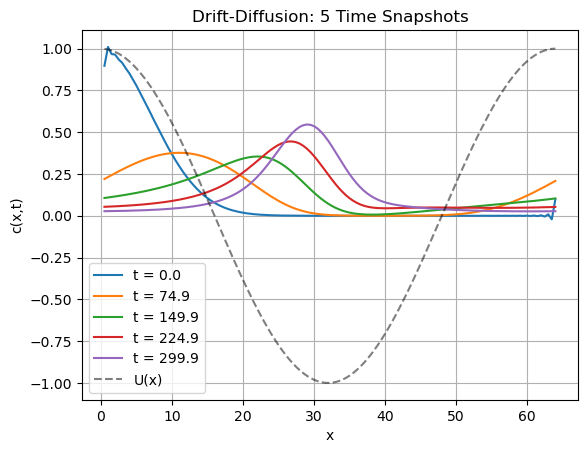

In [9]:
import numpy as np
import matplotlib.pyplot as plt

# Parameters
delt = 0.1    # temporal resolution
delx = 0.5    # spatial resolution
D = 0.15      # diffusion constant
L = 128       # system size
N = 3000      # number of iterations

# Grid
x = np.arange(1, L + 1)

# Initial condition
c0 = np.exp(-((x) * delx)**2 / 100)
c = c0.copy()

# FFT
cc = np.fft.fft(c)

# Potential and its gradient
U = -np.cos(2 * np.pi / L * (x - L/2))
Up = (2 * np.pi / (L * delx)) * np.sin(2 * np.pi / L * (x - L/2))

# k modes
K = (2 * np.pi / (L * delx)) * np.concatenate((
    np.arange(0, L//2),
    np.arange(-L//2, 0)
))

# Storage
cT = np.zeros((L, N))

# Time evolution
for i in range(N):
    rho = Up * c
    # rho = (0.01 * (x - L/2) * delx) * c   # alternative drift

    crho = np.fft.fft(rho)

    cc = cc + delt * (-D * (K**2) * cc + 1j * K * crho)

    c = np.real(np.fft.ifft(cc))
    cT[:, i] = c

x_plot = x*delx
plt.figure()

# pick 5 equally spaced time indices
idx = np.linspace(0, N-1, 5, dtype=int)

for i in idx:
    plt.plot(x_plot, cT[:, i], label=f"t = {i*delt:.1f}")

# optional: plot potential for reference (scaled for visibility)
plt.plot(x_plot, U, 'k--', alpha=0.5, label='U(x)')

plt.xlabel("x")
plt.ylabel("c(x,t)")
plt.title("Drift-Diffusion: 5 Time Snapshots")
plt.legend()
plt.grid()

plt.show()

[1.0, 1.4212670403551895, 1.7088007490635062, 1.93597520645281, 2.2072607458114235, 2.4339268682522075, 2.6668333281253256, 2.8830539363667826, 3.0133038346638727, 3.1553129797216632, 3.325056390499265, 3.451955967274206, 3.5877569594385847, 3.778888725538237, 3.8874155939389863, 4.025916044827563, 4.123105625617661, 4.228947859692763, 4.344191524323024, 4.456007181322759, 4.608687448721165, 4.68444233607374, 4.800833261007926, 4.859629615515981, 4.878524367060187, 4.966689037980936, 5.023146424304193, 5.126792369503567, 5.248999904743759, 5.404442616958756, 5.4560058650994865, 5.483429583755043, 5.618540735813882, 5.688233469188831, 5.704734875522262, 5.738292428937375, 5.809647149354253, 5.860375414595895, 5.909991539757058, 6.006995921423621, 6.062342781466584, 6.1540230743798805, 6.265460876902831, 6.376205768323354, 6.447325026706812, 6.501384467942193, 6.576321160040772, 6.631138665417878, 6.744479223779994, 6.839298209611861, 6.98913442423309, 7.006282894659622, 7.12797306392216

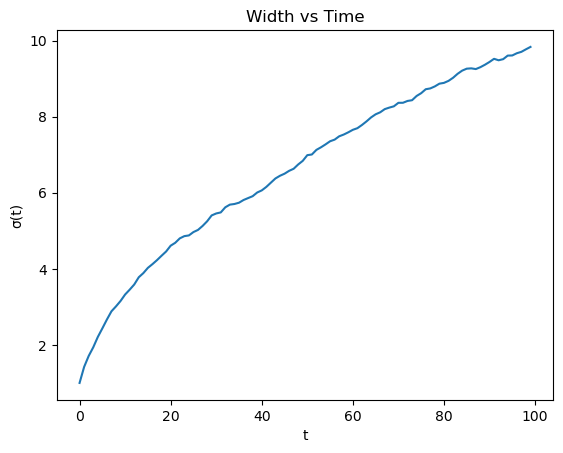

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

n = 100          # number of time steps
l = 1000         # number of random walkers (ensemble size)

L = np.zeros(l)  # initial positions of all walkers (all start at x = 0)
L_t = []         # will store snapshots of full system at each time step

# time evolution loop
for j in range(n):
    for i in range(l):
        r = np.random.random()   # uniform random number in [0,1]

        if r <= 0.5:
            L[i] += 1           # step right (+1)
        else:
            L[i] -= 1           # step left (-1)

    L_t.append(L.copy())        # store full configuration at time j


# function to compute standard deviation (width of distribution)
def sigma(L_snapshot):
    rho = {}  # dictionary for probability distribution P(x)

    # build histogram: count how many walkers at each position
    for pos in L_snapshot:
        rho[pos] = rho.get(pos, 0) + 1

    total = len(L_snapshot)  # total number of walkers

    sigma2 = 0  # will store <x^2>

    # compute second moment: <x^2> = sum x^2 P(x)
    for x, count in rho.items():
        sigma2 += x**2 * (count / total)

    return sigma2**0.5  # σ = sqrt(<x^2>) since mean ≈ 0


sigma_t = []  # store width vs time

# compute width at each time step
for i in range(n):
    sigma_t.append(sigma(L_t[i]))


print(sigma_t)  # print time evolution of width

# plot σ(t)
plt.plot(range(n), sigma_t)
plt.xlabel('t')                 # time
plt.ylabel('σ(t)')              # width (standard deviation)
plt.title('Width vs Time (Random Walk Diffusion)')
plt.show()

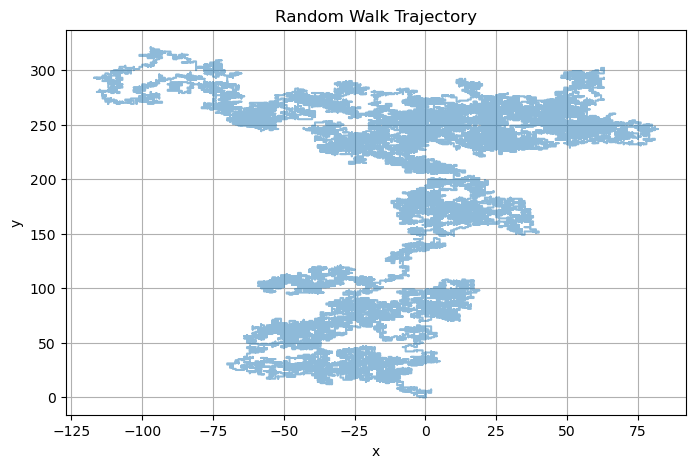

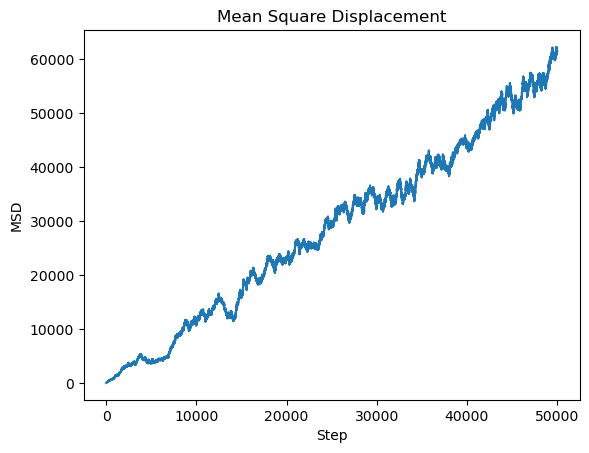

In [3]:
import numpy as np
import matplotlib.pyplot as plt

# Parameters
N = 50000  # number of time steps
Nre = 10   # number of realizations

# Pre‑allocate array for mean‑square displacement of each realization
msd = np.zeros((N, Nre))
X = np.array(N)  # time steps array
Y = np.array(N)  # time steps array

for ire in range(Nre):
    # walker position arrays (initial position at origin)
    x = np.zeros(N)
    y = np.zeros(N)
    for i in range(1, N):
        ro = np.random.rand()  # orientation selector
        rd = np.random.rand()  # displacement selector
        if ro >= 0.5:
            # move in x direction, y stays the same
            y[i] = y[i-1]
            x[i] = x[i-1] + (1 if rd >= 0.5 else -1)
        else:
            # move in y direction, x stays the same
            x[i] = x[i-1]
            y[i] = y[i-1] + (1 if rd >= 0.5 else -1)
    # squared displacement for this realization
    
    msd[:, ire] = x**2 + y**2
    X = x
    Y = y

# Mean square displacement across realizations
MSD = msd.mean(axis=1)

plt.figure(figsize=(8, 5))
plt.plot(X, Y, alpha=0.5)  # plot one trajectory for visualization
plt.xlabel('x')
plt.ylabel('y')
plt.title('Random Walk Trajectory')
plt.grid()
plt.show()
# Plot the result
plt.plot(MSD)
plt.title('Mean Square Displacement')
plt.xlabel('Step')
plt.ylabel('MSD')
plt.show()


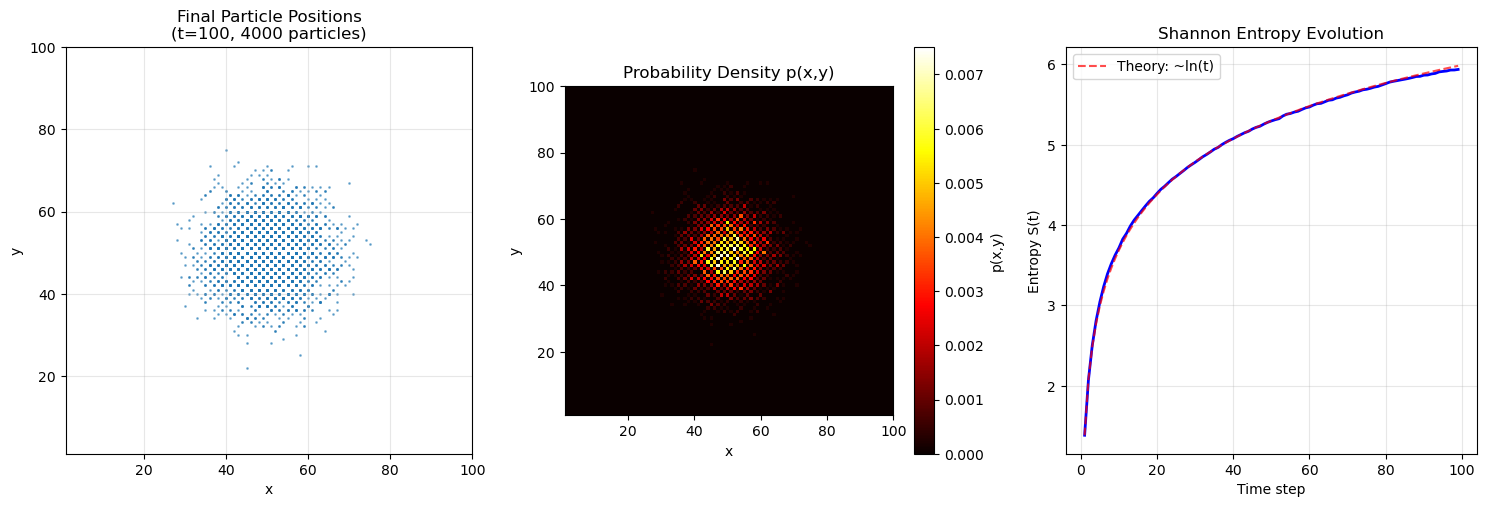

Initial entropy: 1.3862
Final entropy: 5.9361
Max possible (uniform): 9.2103


In [4]:
"""
Vibe-coded Multi-Particle Random Walk with Entropy
Many walkers + probability density + Shannon entropy
"""

import numpy as np
import matplotlib.pyplot as plt

# === STEP 1: SETUP ===
N = 100        # Number of time steps
Np = 4000      # Number of particles
L = 100        # Lattice size (L x L grid)

# All particle positions: x[time, particle]
x = np.zeros((N, Np), dtype=int)
y = np.zeros((N, Np), dtype=int)

# Start all particles at center
x[0, :] = L // 2
y[0, :] = L // 2

# Storage for probability density and entropy
pN_t = np.zeros((L, L, N-1))  # Probability density at each time
S = np.zeros(N-1)             # Entropy at each time

# === STEP 2: SIMULATE ALL PARTICLES ===
for i in range(1, N):
    # Grid to count particles at each site
    c = np.zeros((L, L), dtype=int)

    for ip in range(Np):
        # Same random walk as before
        ro = np.random.rand()
        rd = np.random.rand()

        if ro >= 0.5:
            # Move in x
            y[i, ip] = y[i-1, ip]
            if rd >= 0.5:
                x[i, ip] = x[i-1, ip] + 1
            else:
                x[i, ip] = x[i-1, ip] - 1
        else:
            # Move in y
            x[i, ip] = x[i-1, ip]
            if rd >= 0.5:
                y[i, ip] = y[i-1, ip] + 1
            else:
                y[i, ip] = y[i-1, ip] - 1

        # === STEP 3: PERIODIC BOUNDARY CONDITIONS ===
        # Wrap around: if > L, go to 1; if < 1, go to L
        # Using modulo (but careful: MATLAB is 1-indexed, Python 0-indexed)
        x[i, ip] = ((x[i, ip] - 1) % L) + 1
        y[i, ip] = ((y[i, ip] - 1) % L) + 1

        # Count this particle on the grid (convert to 0-indexed for array)
        c[x[i, ip]-1, y[i, ip]-1] += 1

    # === STEP 4: COMPUTE PROBABILITY DENSITY ===
    pN_t[:, :, i-1] = c / Np  # Normalize by total particles

    # === STEP 5: COMPUTE SHANNON ENTROPY ===
    # S = -sum(p * ln(p))
    # Handle p=0 by setting ln(0)*0 = 0
    p_flat = pN_t[:, :, i-1].flatten()
    p_nonzero = p_flat[p_flat > 0]  # Only non-zero probabilities
    S[i-1] = -np.sum(p_nonzero * np.log(p_nonzero))

# === STEP 6: VISUALIZE ===
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# Plot 1: Final particle positions
axes[0].scatter(x[-1, :], y[-1, :], s=1, alpha=0.5)
axes[0].set_xlim(1, L)
axes[0].set_ylim(1, L)
axes[0].set_xlabel('x')
axes[0].set_ylabel('y')
axes[0].set_title(f'Final Particle Positions\n(t={N}, {Np} particles)')
axes[0].set_aspect('equal')
axes[0].grid(True, alpha=0.3)

# Plot 2: Probability density heatmap at final time
im = axes[1].imshow(pN_t[:, :, -1].T, origin='lower', cmap='hot',
                     extent=[1, L, 1, L])
axes[1].set_xlabel('x')
axes[1].set_ylabel('y')
axes[1].set_title('Probability Density p(x,y)')
plt.colorbar(im, ax=axes[1], label='p(x,y)')

# Plot 3: Entropy vs time
axes[2].plot(range(1, N), S, 'b-', linewidth=2)
axes[2].set_xlabel('Time step')
axes[2].set_ylabel('Entropy S(t)')
axes[2].set_title('Shannon Entropy Evolution')
axes[2].grid(True, alpha=0.3)

# Also plot theoretical expectation for diffusion
# For 2D diffusion from point source: variance grows as 2*D*t
# Entropy ~ ln(t) for spreading Gaussian
axes[2].plot(range(1, N), S[0] + np.log(np.arange(1, N)), 'r--',
              label='Theory: ~ln(t)', alpha=0.7)
axes[2].legend()

plt.tight_layout()
plt.savefig('entropy_random_walk.png', dpi=150)
plt.show()

print(f"Initial entropy: {S[0]:.4f}")
print(f"Final entropy: {S[-1]:.4f}")
print(f"Max possible (uniform): {np.log(L*L):.4f}")

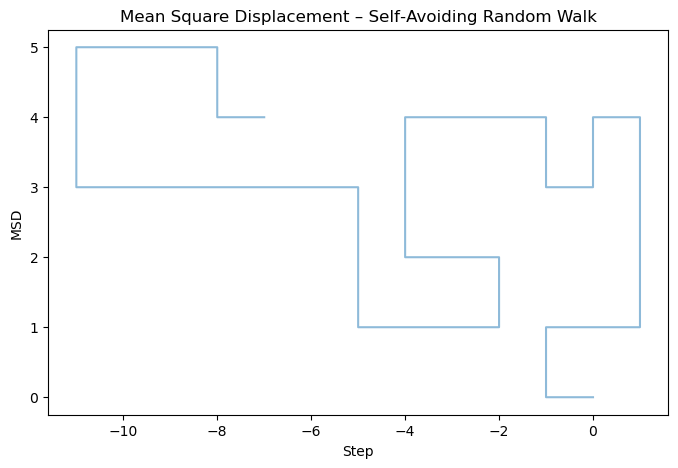

In [21]:
import numpy as np
import matplotlib.pyplot as plt

# ---- Parameters -------------------------------------------------
N  = 50000        # maximum number of steps per walk
Nre = 10          # number of realizations

# ---- Storage ----------------------------------------------------
# mean‑square displacement for each realization (same shape as original example)
msd = np.zeros((N, Nre))

for ire in range(Nre):
    # walker position arrays (start at origin)
    x = np.zeros(N, dtype=int)
    y = np.zeros(N, dtype=int)
    # set of visited lattice points (store as tuples)
    visited = {(0, 0)}
    stuck = False

    for i in range(1, N):
        # try to make a move – keep trying until a non‑visited neighbour is found
        # (or give up if all four neighbours are already visited)
        attempts = 0
        while True:
            ro = np.random.rand()   # choose axis (x or y)
            rd = np.random.rand()   # choose direction (+1 / -1)
            dx, dy = (1 if rd >= 0.5 else -1, 0) if ro >= 0.5 else (0, 1 if rd >= 0.5 else -1)
            nx, ny = x[i-1] + dx, y[i-1] + dy
            if (nx, ny) not in visited:
                # valid step
                x[i] = nx
                y[i] = ny
                visited.add((nx, ny))
                break
            else:
                attempts += 1
                if attempts >= 4:
                    # all four neighbours already visited – self‑avoiding walk is stuck
                    stuck = True
                    break
        if stuck:
            # fill remaining steps with the last position (walk ends early)
            x[i:] = x[i-1]
            y[i:] = y[i-1]
            break

    # squared displacement for this realization (up to the point we stopped)
    msd[:, ire] = x**2 + y**2

# ---- Mean square displacement across realizations ----------------
MSD = msd.mean(axis=1)

# ---- Plot -------------------------------------------------------
plt.figure(figsize=(8, 5))
plt.plot(x, y, alpha=0.5)  # plot one trajectory for visualization
# plt.plot(MSD)
plt.title('Mean Square Displacement – Self‑Avoiding Random Walk')
plt.xlabel('Step')
plt.ylabel('MSD')
plt.show()